##### Regresión Logística en Machine Learning
###### Adriana cruz Modesto
###### Marijose Contla Que
###### Karol Yazmin Aguilar Hernandez
###### Yonathan Beltran Velazquez


# Importar las librerías

##### Antes de comenzar es necesario importar las bibliotecas que contienen las herramientas para trabajar con datos, 
##### entrenar el modelo y visualizar los resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Cargar el conjunto de datos

###### El siguiente paso consiste en cargar el conjunto de datos que utilizará el modelo para aprender.

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

# Dividir los datos

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Entrenar el modelo

In [4]:
modelo = LogisticRegression(max_iter=5000)

modelo.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [5]:
# Realizar predicciones utilizando los datos de prueba
predicciones = modelo.predict(X_test)

# Mostrar las primeras 20 predicciones
print("Primeras 20 predicciones realizadas por el modelo:\n")
print(predicciones[:20])

Primeras 20 predicciones realizadas por el modelo:

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]


# Paso 7. Evaluar el modelo mediante la Precisión (Accuracy)

###### Después de realizar las predicciones, es necesario comprobar qué tan bien se desempeñó el modelo de Regresión Logística.

In [6]:
# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, predicciones)

# Mostrar el resultado
print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.9766081871345029


# Paso 8. Evaluar el modelo mediante la Matriz de Confusión

###### Aunque la precisión (Accuracy) proporciona una idea general del rendimiento del modelo, 
###### esta métrica no permite conocer exactamente en qué casos acertó o se equivocó.

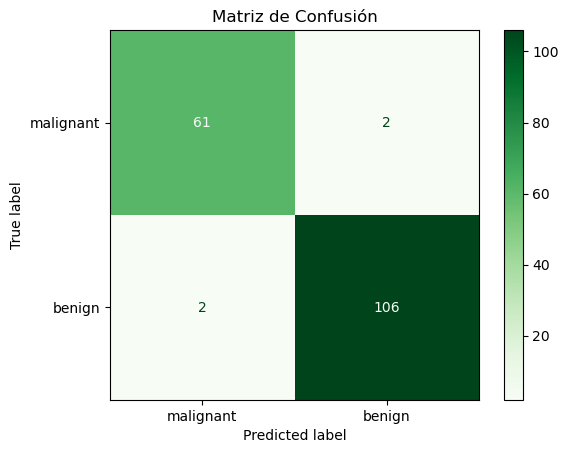

In [7]:
# Calcular la matriz de confusión
matriz = confusion_matrix(y_test, predicciones)

# Mostrar la matriz mediante una gráfica
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=cancer.target_names
)

disp.plot(cmap="Greens")

plt.title("Matriz de Confusión")
plt.show()

# Paso 9. Analizar la importancia de las variables mediante los coeficientes del modelo

###### Una vez entrenado y evaluado el modelo de Regresión Logística, es posible analizar cuáles fueron las variables
###### que tuvieron mayor influencia durante el proceso de clasificación.


In [8]:
# Obtener los coeficientes del modelo
coeficientes = pd.Series(
    modelo.coef_[0],
    index=cancer.feature_names
)

# Obtener el valor absoluto de cada coeficiente
coeficientes = coeficientes.abs()

# Ordenar de mayor a menor importancia
coeficientes = coeficientes.sort_values(ascending=False)

# Mostrar las diez variables más importantes
print("Importancia de cada variable:\n")
print(coeficientes.head(10))

Importancia de cada variable:

texture error           1.360274
worst concavity         1.348911
mean radius             1.069848
worst symmetry          0.724102
worst compactness       0.703384
mean concavity          0.520967
worst concave points    0.509359
worst texture           0.505093
perimeter error         0.441146
mean perimeter          0.389648
dtype: float64


# Paso 10. Visualizar la importancia de las variables mediante una gráfica de barras

###### Después de obtener los coeficientes de la Regresión Logística y ordenar las variables según su nivel de influencia,
###### es recomendable representarlas mediante una gráfica de barras.

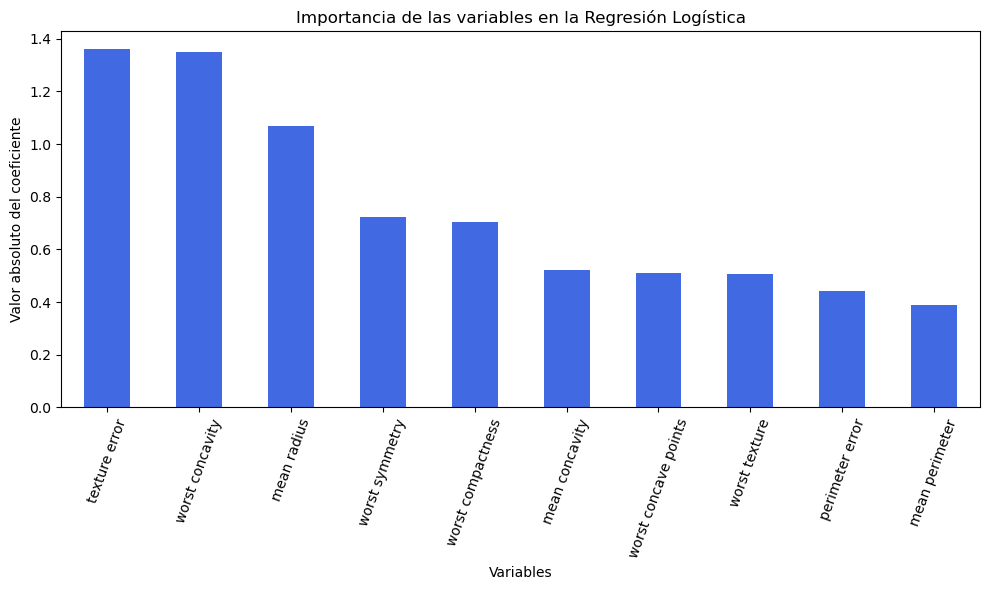

In [9]:
# Crear una figura para la gráfica
plt.figure(figsize=(10,6))

# Graficar las 10 variables más importantes
coeficientes.head(10).plot(
    kind="bar",
    color="royalblue"
)

# Agregar título y etiquetas
plt.title("Importancia de las variables en la Regresión Logística")
plt.ylabel("Valor absoluto del coeficiente")
plt.xlabel("Variables")

# Rotar los nombres de las variables
plt.xticks(rotation=70)

# Ajustar automáticamente los elementos de la gráfica
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# Paso 11. Realizar una predicción con un nuevo dato
###### Hasta este momento, el modelo de Regresión Logística ha sido entrenado utilizando un conjunto de datos y posteriormente evaluado mediante diferentes métricas,
###### como la precisión (Accuracy) y la matriz de confusión.

In [10]:
# Seleccionar un registro del conjunto de datos como ejemplo
dato_nuevo = pd.DataFrame(
    [X.iloc[0]],
    columns=cancer.feature_names
)

# Realizar la predicción
prediccion = modelo.predict(dato_nuevo)

# Obtener las probabilidades de cada clase
probabilidades = modelo.predict_proba(dato_nuevo)

# Mostrar el registro utilizado
print("Dato nuevo:\n")
print(dato_nuevo)

# Mostrar la clase predicha
print("\nClase predicha:")
print(cancer.target_names[prediccion[0]])

# Mostrar las probabilidades
print("\nProbabilidades por clase:")

for clase, prob in zip(cancer.target_names, probabilidades[0]):
    print(f"{clase}: {prob:.2%}")

Dato nuevo:

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0           0.1184   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0            0.2776          0.3001               0.1471         0.2419   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                 0.07871  ...         25.38          17.33            184.6   

   worst area  worst smoothness  worst compactness  worst concavity  \
0      2019.0            0.1622             0.6656           0.7119   

   worst concave points  worst symmetry  worst fractal dimension  
0                0.2654          0.4601                   0.1189  

[1 rows x 30 columns]

Clase predicha:
malignant

Probabilidades por clase:
malignant: 100.00%
benign: 0.00%


# Conclusión

###### Durante el desarrollo de esta práctica fue posible comprender el funcionamiento de la Regresión Logística, uno de los algoritmos de aprendizaje supervisado más utilizados para resolver problemas de clasificación. 
###### A lo largo de la actividad se realizó todo el proceso necesario para construir un modelo de Machine Learning, comenzando con la importación de las bibliotecas necesarias, la carga y preparación del conjunto de datos, el entrenamiento del modelo 
###### y la evaluación de su desempeño mediante diferentes métricas.

###### Se trabajó con el conjunto de datos Breast Cancer Wisconsin, el cual contiene información obtenida de estudios médicos realizados sobre tumores mamarios. Gracias a este conjunto de datos, 
###### el modelo aprendió a identificar patrones presentes en las características de cada paciente para clasificar correctamente los tumores como benignos o malignos.